# **FRAMEWORK V7 DATASET MAESTRO - MODELADO**


## **M0. Configuración del Experimento**

In [1]:
#==========================================================================================
# SCRIPT 32
# CONFIGURACIÓN DEL EXPERIMENTO DE MODELADO
#==========================================================================================

EXPERIMENTO = "Exp01"

DOMINIO = "Gestión Hídrica"

VARIABLE_OBJETIVO = "irca"

METODO_TRANSFORMACION = "Escalado MinMax"

In [2]:
#==========================================================================================
# LIBRERÍAS
#==========================================================================================

import numpy as np

import pandas as pd

import tensorflow as tf

from tensorflow import keras

print()

print("="*90)
print("LIBRERÍAS CARGADAS")
print("="*90)


LIBRERÍAS CARGADAS


In [3]:
#==========================================================================================
# CARGA DE SECUENCIAS TEMPORALES
#==========================================================================================
import numpy as np
import pandas as pd

# Base URL for the sequences and metadata
base_url = "https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/Exp01/"

# URLs completas de los archivos
x_sequence_url = base_url + "secuencias_X.npy"
y_sequence_url = base_url + "secuencias_y.npy"
metadata_sequence_url = base_url + "metadata_secuencias.csv"

# Nombres de archivo locales
x_sequence_filename = "secuencias_X.npy"
y_sequence_filename = "secuencias_y.npy"
metadata_sequence_filename = "metadata_secuencias.csv"

# Descargar los archivos
!wget -O {x_sequence_filename} {x_sequence_url}
!wget -O {y_sequence_filename} {y_sequence_url}
!wget -O {metadata_sequence_filename} {metadata_sequence_url}

secuencias_X = np.load(x_sequence_filename)
secuencias_y = np.load(y_sequence_filename)
metadata = pd.read_csv(metadata_sequence_filename)

print()

print("="*90)
print("SECUENCIAS CARGADAS")
print("="*90)

print()

print(f"Secuencias X : {secuencias_X.shape}")

print(f"Secuencias y : {secuencias_y.shape}")

print()

display(metadata)

--2026-07-28 16:00:49--  https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/Exp01/secuencias_X.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 396416 (387K) [application/octet-stream]
Saving to: ‘secuencias_X.npy’

secuencias_X.npy    100%[===================>] 387.12K  --.-KB/s    in 0.03s   

2026-07-28 16:00:50 (15.0 MB/s) - ‘secuencias_X.npy’ saved [396416/396416]

--2026-07-28 16:00:50--  https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MACHINE_LEARNING/C13_MACHINE_LEARNING/Transformaciones/Exp01/secuencias_y.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connectin

,Parametro,Valor
0,Dominio,Gestión Hídrica
1,Variable Objetivo,irca
2,Ventana,12
3,Horizonte,1
4,Variables Predictoras,Precipitacion_mm;ONI;Radiacion_Solar;Humedad_R...
5,Variables Modelo,8
6,Numero de Secuencias,516


In [4]:
#==========================================================================================
# VALIDACIÓN DEL EXPERIMENTO
#==========================================================================================

print()

print("="*90)
print("VALIDACIÓN")
print("="*90)

print()

if len(secuencias_X) != len(secuencias_y):

    raise Exception(

        "Las secuencias X y y no tienen la misma cantidad de registros."

    )

print("Secuencias consistentes.")

print()

print(f"Número de muestras : {len(secuencias_X)}")


VALIDACIÓN

Secuencias consistentes.

Número de muestras : 516


## **M1. Construcción de Tensores**

In [5]:
#==========================================================================================
# CONSTRUCCIÓN DEL TENSOR X
#==========================================================================================

X = np.array(

    secuencias_X,

    dtype=np.float32

)

print()

print("="*90)
print("TENSOR X")
print("="*90)

print()

print(f"Forma : {X.shape}")


TENSOR X

Forma : (516, 12, 8)


In [6]:
#==========================================================================================
# CONSTRUCCIÓN DEL TENSOR y
#==========================================================================================

y = np.array(

    secuencias_y,

    dtype=np.float32

)

print()

print("="*90)
print("TENSOR y")
print("="*90)

print()

print(f"Forma : {y.shape}")


TENSOR y

Forma : (516,)


In [7]:
#==========================================================================================
# VALIDACIÓN DE LOS TENSORES
#==========================================================================================

print()

print("="*90)
print("VALIDACIÓN")
print("="*90)

print()

print(f"Tensor X : {X.shape}")

print(f"Tensor y : {y.shape}")

print()

print(f"Ventana temporal      : {X.shape[1]}")

print(f"Variables predictoras : {X.shape[2]}")

print()

if X.shape[0] == y.shape[0]:

    print("Resultado : TENSORES VÁLIDOS")

else:

    raise Exception(

        "El número de muestras entre X e y no coincide."

    )


VALIDACIÓN

Tensor X : (516, 12, 8)
Tensor y : (516,)

Ventana temporal      : 12
Variables predictoras : 8

Resultado : TENSORES VÁLIDOS


In [8]:
#==========================================================================================
# EXPORTACIÓN DEL TENSOR X
#==========================================================================================

import os

CARPETA_TENSORES = f"tensores/{EXPERIMENTO}"

os.makedirs(

    CARPETA_TENSORES,

    exist_ok=True

)

np.save(

    f"{CARPETA_TENSORES}/tensor_X.npy",

    X

)

print()

print("="*90)
print("TENSOR X EXPORTADO")
print("="*90)

print()

print(f"{CARPETA_TENSORES}/tensor_X.npy")


TENSOR X EXPORTADO

tensores/Exp01/tensor_X.npy


In [9]:
#==========================================================================================
# EXPORTACIÓN DEL TENSOR y
#==========================================================================================

np.save(

    f"{CARPETA_TENSORES}/tensor_y.npy",

    y

)

print()

print("="*90)
print("TENSOR y EXPORTADO")
print("="*90)

print()

print(f"{CARPETA_TENSORES}/tensor_y.npy")


TENSOR y EXPORTADO

tensores/Exp01/tensor_y.npy


In [10]:
#==========================================================================================
# METADATA DEL TENSOR
#==========================================================================================

HORIZONTE = metadata.loc[
    metadata["Parametro"] == "Horizonte",
    "Valor"
].iloc[0]

# Recuperar nombres de las variables desde metadata_secuencias
VARIABLES_MODELO = (
    metadata.loc[
        metadata["Parametro"] == "Variables Predictoras",
        "Valor"
    ]
    .iloc[0]
)

metadata_tensor = pd.DataFrame({

    "Parametro":[

        "Experimento",

        "Dominio",

        "Variable Objetivo",

        "Ventana",

        "Horizonte",

        "Variables Predictoras",

        "Variables Modelo",

        "Metodo Transformacion",

        "Numero Secuencias",

        "Fecha Generacion",

        "Tensor X",

        "Tensor y"

    ],

    "Valor":[

        EXPERIMENTO,

        DOMINIO,

        VARIABLE_OBJETIVO,

        X.shape[1],

        HORIZONTE,

        X.shape[2],

        VARIABLES_MODELO,

        METODO_TRANSFORMACION,

        X.shape[0],

        pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),

        "tensor_X.npy",

        "tensor_y.npy"

    ]

})

#==========================================================================================
# EXPORTACIÓN DE LA METADATA
#==========================================================================================

metadata_tensor.to_csv(

    f"{CARPETA_TENSORES}/metadata_tensor.csv",

    index=False,

    encoding="utf-8-sig"

)

metadata_tensor.to_excel(

    f"{CARPETA_TENSORES}/metadata_tensor.xlsx",

    index=False

)

print()

print("="*90)
print("METADATA DEL TENSOR EXPORTADA")
print("="*90)

print()

print(f"{CARPETA_TENSORES}/metadata_tensor.csv")

print(f"{CARPETA_TENSORES}/metadata_tensor.xlsx")

print()

display(metadata_tensor)



METADATA DEL TENSOR EXPORTADA

tensores/Exp01/metadata_tensor.csv
tensores/Exp01/metadata_tensor.xlsx



,Parametro,Valor
0,Experimento,Exp01
1,Dominio,Gestión Hídrica
2,Variable Objetivo,irca
3,Ventana,12
4,Horizonte,1
5,Variables Predictoras,8
6,Variables Modelo,Precipitacion_mm;ONI;Radiacion_Solar;Humedad_R...
7,Metodo Transformacion,Escalado MinMax
8,Numero Secuencias,516
9,Fecha Generacion,2026-07-28 16:08


## **M2. División Temporal del Conjunto de Datos**

Objetivo: Dividir los tensores en:

* Entrenamiento (70%)
* Validación (15%)
* Prueba (15%)

manteniendo el orden temporal.

In [11]:
#==========================================================================================
# CONFIGURACIÓN DE LA DIVISIÓN TEMPORAL
#==========================================================================================

PORCENTAJE_TRAIN = 0.70

PORCENTAJE_VALIDACION = 0.15

PORCENTAJE_PRUEBA = 0.15

print()

print("="*90)
print("CONFIGURACIÓN DE LA DIVISIÓN")
print("="*90)

print()

print(f"Entrenamiento : {PORCENTAJE_TRAIN:.0%}")
print(f"Validación    : {PORCENTAJE_VALIDACION:.0%}")
print(f"Prueba        : {PORCENTAJE_PRUEBA:.0%}")


CONFIGURACIÓN DE LA DIVISIÓN

Entrenamiento : 70%
Validación    : 15%
Prueba        : 15%


In [12]:
#==========================================================================================
# CÁLCULO DE LOS ÍNDICES
#==========================================================================================

n = len(X)

indice_train = int(n * PORCENTAJE_TRAIN)

indice_validacion = int(n * (PORCENTAJE_TRAIN + PORCENTAJE_VALIDACION))

print()

print("="*90)
print("ÍNDICES DE CORTE")
print("="*90)

print()

print(f"Total muestras       : {n}")

print(f"Fin entrenamiento    : {indice_train}")

print(f"Fin validación       : {indice_validacion}")


ÍNDICES DE CORTE

Total muestras       : 516
Fin entrenamiento    : 361
Fin validación       : 438


In [13]:
#==========================================================================================
# DIVISIÓN TEMPORAL
#==========================================================================================

X_train = X[:indice_train]

y_train = y[:indice_train]

X_valid = X[indice_train:indice_validacion]

y_valid = y[indice_train:indice_validacion]

X_test = X[indice_validacion:]

y_test = y[indice_validacion:]

In [14]:
#==========================================================================================
# RESUMEN DE LA DIVISIÓN
#==========================================================================================

print()

print("="*90)
print("RESUMEN")
print("="*90)

print()

print(f"Entrenamiento : {X_train.shape}")

print(f"Validación    : {X_valid.shape}")

print(f"Prueba        : {X_test.shape}")


RESUMEN

Entrenamiento : (361, 12, 8)
Validación    : (77, 12, 8)
Prueba        : (78, 12, 8)


In [15]:
#==========================================================================================
# VALIDACIÓN DE LA DIVISIÓN
#==========================================================================================

print()

print("="*90)
print("VALIDACIÓN")
print("="*90)

print()

print(f"Total muestras : {len(X)}")

print(

    f"Total dividido : "

    f"{len(X_train)+len(X_valid)+len(X_test)}"

)

if len(X) == len(X_train)+len(X_valid)+len(X_test):

    print()

    print("Resultado : DIVISIÓN CORRECTA")

else:

    raise Exception(

        "La división temporal presenta inconsistencias."

    )


VALIDACIÓN

Total muestras : 516
Total dividido : 516

Resultado : DIVISIÓN CORRECTA


## **M3. Construcción del Modelo de Machine Learning**

In [16]:
#==========================================================================================
# CONFIGURACIÓN DEL MODELO
#==========================================================================================

TIPO_MODELO = "LSTM"

UNIDADES_LSTM = 32

DROPOUT = 0.20

ACTIVACION = "tanh"

print()

print("="*90)
print("CONFIGURACIÓN DEL MODELO")
print("="*90)

print()

print(f"Modelo              : {TIPO_MODELO}")

print(f"Neuronas LSTM       : {UNIDADES_LSTM}")

print(f"Dropout             : {DROPOUT}")

print(f"Activación          : {ACTIVACION}")


CONFIGURACIÓN DEL MODELO

Modelo              : LSTM
Neuronas LSTM       : 32
Dropout             : 0.2
Activación          : tanh


In [17]:
#==========================================================================================
# CONSTRUCCIÓN DEL MODELO
#==========================================================================================

from tensorflow import keras

if TIPO_MODELO == "LSTM":

    modelo = keras.Sequential([

        keras.layers.Input(

            shape=(

                X_train.shape[1],

                X_train.shape[2]

            )

        ),

        keras.layers.LSTM(

            units=UNIDADES_LSTM,

            activation=ACTIVACION

        ),

        keras.layers.Dropout(

            DROPOUT

        ),

        keras.layers.Dense(

            1

        )

    ])

else:

    raise Exception(

        f"Modelo '{TIPO_MODELO}' no soportado por el Framework."

    )

## **M4. Configuración del Entrenamiento**

In [18]:
#==========================================================================================
# CONFIGURACIÓN DEL ENTRENAMIENTO
#==========================================================================================

EPOCAS = 100

BATCH_SIZE = 32

LEARNING_RATE = 0.001

PACIENCIA = 10

print()

print("="*90)
print("CONFIGURACIÓN DEL ENTRENAMIENTO")
print("="*90)

print()

print(f"Épocas           : {EPOCAS}")

print(f"Batch Size       : {BATCH_SIZE}")

print(f"Learning Rate    : {LEARNING_RATE}")

print(f"Early Stopping   : {PACIENCIA}")


CONFIGURACIÓN DEL ENTRENAMIENTO

Épocas           : 100
Batch Size       : 32
Learning Rate    : 0.001
Early Stopping   : 10


In [19]:
#==========================================================================================
# EARLY STOPPING
#==========================================================================================

import tensorflow as tf

early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=PACIENCIA,

    restore_best_weights=True

)

print()

print("="*90)
print("CALLBACKS")
print("="*90)

print()

print("EarlyStopping configurado correctamente.")


CALLBACKS

EarlyStopping configurado correctamente.


In [20]:
#==========================================================================================
# COMPILACIÓN DEL MODELO
#==========================================================================================

modelo.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=LEARNING_RATE

    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy"

    ]

)

print()

print("="*90)
print("MODELO COMPILADO")
print("="*90)

print()

print("Compilación finalizada correctamente.")


MODELO COMPILADO

Compilación finalizada correctamente.


## **M5. Entrenamiento del Modelo**

In [21]:
#==========================================================================================
# ENTRENAMIENTO DEL MODELO
#==========================================================================================

import time

inicio = time.time()

historial = modelo.fit(

    X_train,

    y_train,

    validation_data=(

        X_valid,

        y_valid

    ),

    epochs=EPOCAS,

    batch_size=BATCH_SIZE,

    callbacks=[

        early_stopping

    ],

    verbose=1

)

fin = time.time()

TIEMPO_ENTRENAMIENTO = fin - inicio

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9307 - loss: 1.1249 - val_accuracy: 0.8442 - val_loss: 2.3545
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9335 - loss: 1.0052 - val_accuracy: 0.8442 - val_loss: 2.5136
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9335 - loss: 1.0371 - val_accuracy: 0.8442 - val_loss: 2.5119
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9335 - loss: 0.9694 - val_accuracy: 0.8442 - val_loss: 2.5119
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9363 - loss: 0.7694 - val_accuracy: 0.8442 - val_loss: 2.5263
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9474 - loss: 0.6432 - val_accuracy: 0.8442 - val_loss: 2.5141
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9363 - loss: 0.6099 - val_accuracy: 0.8442 - val_loss: 2.3434
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9363 - loss: 0.5915 - val_accuracy: 0.

In [22]:
#==========================================================================================
# RESUMEN DEL ENTRENAMIENTO
#==========================================================================================

print()

print("="*90)
print("ENTRENAMIENTO FINALIZADO")
print("="*90)

print()

print(f"Épocas ejecutadas : {len(historial.history['loss'])}")

print(f"Tiempo (segundos) : {TIEMPO_ENTRENAMIENTO:.2f}")


ENTRENAMIENTO FINALIZADO

Épocas ejecutadas : 50
Tiempo (segundos) : 13.65


In [23]:
#==========================================================================================
# HISTORIAL DEL ENTRENAMIENTO
#==========================================================================================

historial_df = pd.DataFrame(

    historial.history

)

print()

print("="*90)
print("HISTORIAL")
print("="*90)

print()

display(historial_df.head())


HISTORIAL



,accuracy,loss,val_accuracy,val_loss
0,0.930748,1.124864,0.844156,2.354533
1,0.933518,1.005158,0.844156,2.513584
2,0.933518,1.037135,0.844156,2.511911
3,0.933518,0.969355,0.844156,2.511911
4,0.936288,0.769410,0.844156,2.526290


In [24]:
#==========================================================================================
# MÉTRICAS FINALES
#==========================================================================================

LOSS_FINAL = historial.history["loss"][-1]

VAL_LOSS_FINAL = historial.history["val_loss"][-1]

ACC_FINAL = historial.history["accuracy"][-1]

VAL_ACC_FINAL = historial.history["val_accuracy"][-1]

print()

print("="*90)
print("RESULTADOS FINALES")
print("="*90)

print()

print(f"Loss entrenamiento      : {LOSS_FINAL:.4f}")

print(f"Loss validación         : {VAL_LOSS_FINAL:.4f}")

print()

print(f"Accuracy entrenamiento  : {ACC_FINAL:.4f}")

print(f"Accuracy validación     : {VAL_ACC_FINAL:.4f}")


RESULTADOS FINALES

Loss entrenamiento      : 0.5450
Loss validación         : 1.2467

Accuracy entrenamiento  : 0.9612
Accuracy validación     : 0.8442


## **M6. Evaluación del Modelo**

In [25]:
#==========================================================================================
# EVALUACIÓN DEL MODELO
#==========================================================================================

LOSS_TEST, ACC_TEST = modelo.evaluate(

    X_test,

    y_test,

    verbose=0

)

print()

print("="*90)
print("EVALUACIÓN DEL MODELO")
print("="*90)

print()

print(f"Loss prueba     : {LOSS_TEST:.4f}")

print(f"Accuracy prueba : {ACC_TEST:.4f}")


EVALUACIÓN DEL MODELO

Loss prueba     : 1.5911
Accuracy prueba : 0.8462


In [26]:
#==========================================================================================
# PREDICCIONES
#==========================================================================================

probabilidades = modelo.predict(

    X_test,

    verbose=0

)

predicciones = (

    probabilidades >= 0.50

).astype(int)

print()

print("="*90)
print("PREDICCIONES")
print("="*90)

print()

print(f"Predicciones realizadas : {len(predicciones)}")


PREDICCIONES

Predicciones realizadas : 78


In [27]:
#==========================================================================================
# COMPARACIÓN
#==========================================================================================

comparacion = pd.DataFrame({

    "Real": y_test.astype(int),

    "Probabilidad": probabilidades.flatten(),

    "Predicción": predicciones.flatten()

})

display(comparacion.head(20))

,Real,Probabilidad,Predicción
0,0,-0.889430,0
1,0,-0.930354,0
2,0,-0.984444,0
3,0,-0.984820,0
4,0,-0.958765,0
5,0,-0.872671,0
6,0,-0.840530,0
7,0,-0.724497,0
8,0,-0.704930,0
9,0,-0.654119,0


## **M7. Visualización del Entrenamiento**

In [28]:
#==========================================================================================
# LIBRERÍA
#==========================================================================================

import matplotlib.pyplot as plt

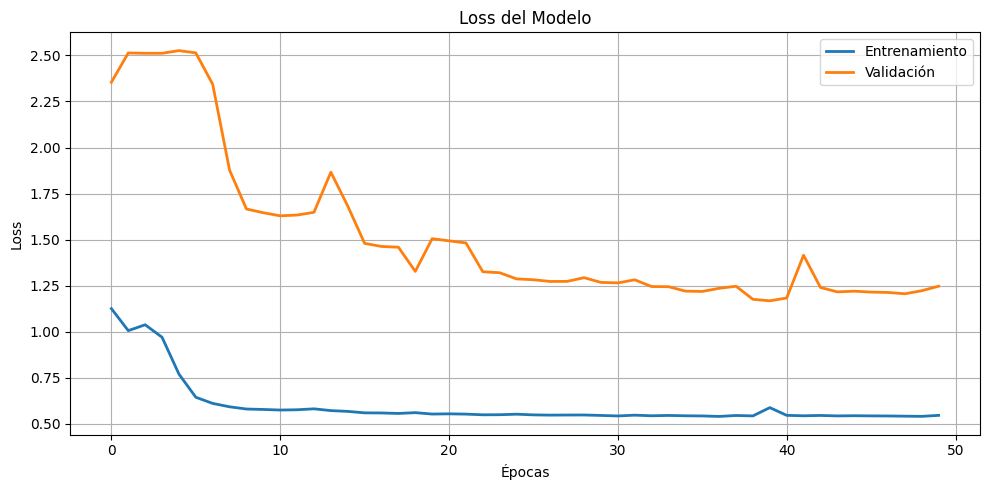

In [29]:
#==========================================================================================
# CURVA DE LOSS
#==========================================================================================

plt.figure(figsize=(10,5))

plt.plot(

    historial.history["loss"],

    label="Entrenamiento",

    linewidth=2

)

plt.plot(

    historial.history["val_loss"],

    label="Validación",

    linewidth=2

)

plt.title("Loss del Modelo")

plt.xlabel("Épocas")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(

    "loss_experimento.png",

    dpi=300

)

plt.show()

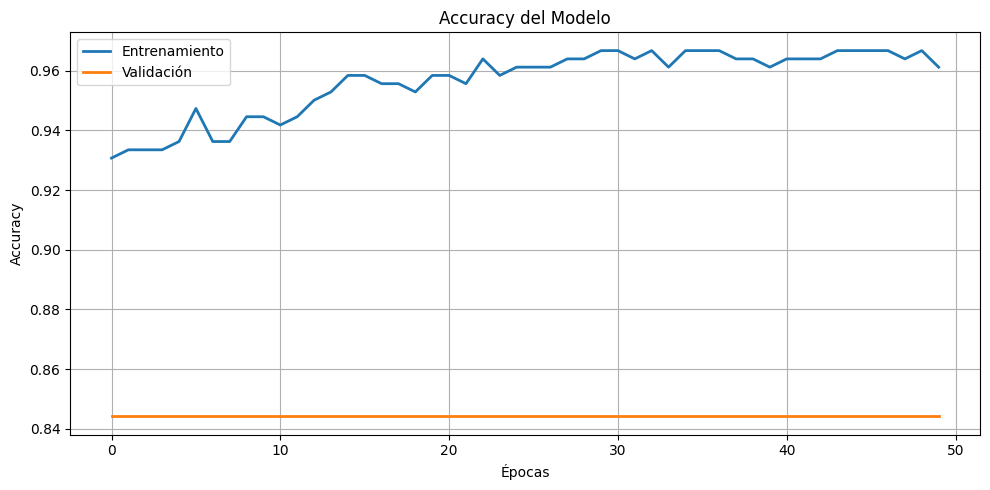

In [30]:
#==========================================================================================
# CURVA DE ACCURACY
#==========================================================================================

plt.figure(figsize=(10,5))

plt.plot(

    historial.history["accuracy"],

    label="Entrenamiento",

    linewidth=2

)

plt.plot(

    historial.history["val_accuracy"],

    label="Validación",

    linewidth=2

)

plt.title("Accuracy del Modelo")

plt.xlabel("Épocas")

plt.ylabel("Accuracy")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(

    "accuracy_experimento.png",

    dpi=300

)

plt.show()

In [31]:
#==========================================================================================
# EXPORTACIÓN
#==========================================================================================

print()

print("="*90)
print("GRÁFICAS EXPORTADAS")
print("="*90)

print()

print("loss_experimento.png")

print("accuracy_experimento.png")


GRÁFICAS EXPORTADAS

loss_experimento.png
accuracy_experimento.png


## **M8. Guardar el modelo entrenado**

In [32]:
#==========================================================================================
# PERSISTENCIA DEL MODELO
#==========================================================================================

NOMBRE_MODELO = f"modelo_{EXPERIMENTO}_{VARIABLE_OBJETIVO}.keras"

modelo.save(

    NOMBRE_MODELO

)

print()

print("="*90)
print("MODELO EXPORTADO")
print("="*90)

print()

print(NOMBRE_MODELO)


MODELO EXPORTADO

modelo_Exp01_irca.keras


## **M9. Registro del Experimento**

In [33]:
#==========================================================================================
# FECHA DEL EXPERIMENTO
#==========================================================================================

from datetime import datetime

FECHA_EJECUCION = datetime.now()

print()

print("="*90)
print("FECHA DEL EXPERIMENTO")
print("="*90)

print()

print(FECHA_EJECUCION)


FECHA DEL EXPERIMENTO

2026-07-28 16:20:09.806662


In [34]:
#==========================================================================================
# REGISTRO DEL EXPERIMENTO
#==========================================================================================

registro = pd.DataFrame({

    "Experimento":[EXPERIMENTO],

    "Fecha":[FECHA_EJECUCION],

    "Dominio":[DOMINIO],

    "Variable_Objetivo":[VARIABLE_OBJETIVO],

    "Modelo":[TIPO_MODELO],

    "Metodo_Transformacion":[METODO_TRANSFORMACION],

    "Ventana":[X.shape[1]],

    "Variables_Predictoras":[X.shape[2]],

    "Muestras":[X.shape[0]],

    "Train":[len(X_train)],

    "Validacion":[len(X_valid)],

    "Prueba":[len(X_test)],

    "Neuronas":[UNIDADES_LSTM],

    "Dropout":[DROPOUT],

    "Learning_Rate":[LEARNING_RATE],

    "Batch_Size":[BATCH_SIZE],

    "Epocas_Config":[EPOCAS],

    "Epocas_Ejecutadas":[len(historial.history["loss"])],

    "Loss_Train":[LOSS_FINAL],

    "Loss_Validacion":[VAL_LOSS_FINAL],

    "Loss_Prueba":[LOSS_TEST],

    "Accuracy_Train":[ACC_FINAL],

    "Accuracy_Validacion":[VAL_ACC_FINAL],

    "Accuracy_Prueba":[ACC_TEST],

    "Tiempo_Segundos":[TIEMPO_ENTRENAMIENTO]

})

print()

print("="*90)
print("REGISTRO DEL EXPERIMENTO")
print("="*90)

print()

display(registro)


REGISTRO DEL EXPERIMENTO



,Experimento,Fecha,Dominio,Variable_Objetivo,Modelo,Metodo_Transformacion,Ventana,Variables_Predictoras,Muestras,Train,...,Batch_Size,Epocas_Config,Epocas_Ejecutadas,Loss_Train,Loss_Validacion,Loss_Prueba,Accuracy_Train,Accuracy_Validacion,Accuracy_Prueba,Tiempo_Segundos
0,Exp01,2026-07-28 16:20:09.806662,Gestión Hídrica,irca,LSTM,Escalado MinMax,12,8,516,361,...,32,100,50,0.544952,1.246683,1.591098,0.961219,0.844156,0.846154,13.653877


In [35]:
#==========================================================================================
# EXPORTACIÓN
#==========================================================================================

nombre_csv = f"registro_{EXPERIMENTO}.csv"

nombre_excel = f"registro_{EXPERIMENTO}.xlsx"

registro.to_csv(

    nombre_csv,

    index=False,

    encoding="utf-8-sig"

)

registro.to_excel(

    nombre_excel,

    index=False

)

print()

print("="*90)
print("ARCHIVOS GENERADOS")
print("="*90)

print()

print(nombre_csv)

print(nombre_excel)


ARCHIVOS GENERADOS

registro_Exp01.csv
registro_Exp01.xlsx


In [36]:
#==========================================================================================
# RESUMEN
#==========================================================================================

print()

print("="*90)
print("FRAMEWORK DE MODELADO FINALIZADO")
print("="*90)

print()

print(f"Experimento        : {EXPERIMENTO}")

print(f"Modelo             : {TIPO_MODELO}")

print(f"Objetivo           : {VARIABLE_OBJETIVO}")

print(f"Muestras           : {len(X)}")

print(f"Accuracy Prueba    : {ACC_TEST:.4f}")

print(f"Tiempo             : {TIEMPO_ENTRENAMIENTO:.2f} segundos")

print()

print("Proceso completado correctamente.")


FRAMEWORK DE MODELADO FINALIZADO

Experimento        : Exp01
Modelo             : LSTM
Objetivo           : irca
Muestras           : 516
Accuracy Prueba    : 0.8462
Tiempo             : 13.65 segundos

Proceso completado correctamente.


## **M10. Bitácora Maestra**

In [37]:
#==========================================================================================
# BITÁCORA MAESTRA DEL FRAMEWORK
#==========================================================================================

import os

ARCHIVO_BITACORA = "bitacora_maestra_experimentos.xlsx"

print()

print("="*90)
print("BITÁCORA MAESTRA")
print("="*90)

print()

print(ARCHIVO_BITACORA)


BITÁCORA MAESTRA

bitacora_maestra_experimentos.xlsx


In [38]:
#==========================================================================================
# CARGA DE LA BITÁCORA
#==========================================================================================

if os.path.exists(ARCHIVO_BITACORA):

    bitacora = pd.read_excel(

        ARCHIVO_BITACORA

    )

else:

    bitacora = pd.DataFrame()

In [39]:
#==========================================================================================
# AGREGAR REGISTRO Y ORDENAMIENTO
#==========================================================================================

# Agregar el registro del experimento actual a la bitácora
if bitacora.empty:
    bitacora = registro.copy()
else:
    bitacora = pd.concat([bitacora, registro], ignore_index=True)

# Ordenar la bitácora
if not bitacora.empty:
    bitacora = bitacora.sort_values(
        by="Experimento"
    ).reset_index(
        drop=True
    )

In [40]:
#==========================================================================================
# EXPORTACIÓN
#==========================================================================================

bitacora.to_excel(

    ARCHIVO_BITACORA,

    index=False

)

bitacora.to_csv(

    "bitacora_maestra_experimentos.csv",

    index=False,

    encoding="utf-8-sig"

)

In [41]:
#==========================================================================================
# HISTÓRICO
#==========================================================================================

print()

print("="*90)
print("HISTÓRICO DEL FRAMEWORK")
print("="*90)

print()

display(bitacora)


HISTÓRICO DEL FRAMEWORK



,Experimento,Fecha,Dominio,Variable_Objetivo,Modelo,Metodo_Transformacion,Ventana,Variables_Predictoras,Muestras,Train,...,Batch_Size,Epocas_Config,Epocas_Ejecutadas,Loss_Train,Loss_Validacion,Loss_Prueba,Accuracy_Train,Accuracy_Validacion,Accuracy_Prueba,Tiempo_Segundos
0,Exp01,2026-07-28 16:20:09.806662,Gestión Hídrica,irca,LSTM,Escalado MinMax,12,8,516,361,...,32,100,50,0.544952,1.246683,1.591098,0.961219,0.844156,0.846154,13.653877


## **M11. Centro Analítico del Framework**

In [42]:
#==========================================================================================
# SCRIPT 43
# CENTRO ANALÍTICO DEL FRAMEWORK
#==========================================================================================

import pandas as pd

ARCHIVO_BITACORA = "bitacora_maestra_experimentos.xlsx"

bitacora = pd.read_excel(

    ARCHIVO_BITACORA

)

print()

print("="*90)
print("CENTRO ANALÍTICO DEL FRAMEWORK")
print("="*90)

print()

display(bitacora.head())


CENTRO ANALÍTICO DEL FRAMEWORK



,Experimento,Fecha,Dominio,Variable_Objetivo,Modelo,Metodo_Transformacion,Ventana,Variables_Predictoras,Muestras,Train,...,Batch_Size,Epocas_Config,Epocas_Ejecutadas,Loss_Train,Loss_Validacion,Loss_Prueba,Accuracy_Train,Accuracy_Validacion,Accuracy_Prueba,Tiempo_Segundos
0,Exp01,2026-07-28 16:20:09.807,Gestión Hídrica,irca,LSTM,Escalado MinMax,12,8,516,361,...,32,100,50,0.544952,1.246683,1.591098,0.961219,0.844156,0.846154,13.653877


In [43]:
import pandas as pd

#==========================================================================================
# RESUMEN GENERAL
#==========================================================================================

print()

print("="*90)
print("RESUMEN GENERAL")
print("="*90)

print()

if not bitacora.empty:
    print(f"Experimentos ejecutados : {len(bitacora)}")
    print(f"Modelos utilizados      : {bitacora['Modelo'].nunique()}")
    print(f"Variables objetivo      : {bitacora['Variable_Objetivo'].nunique()}")
    print(f"Accuracy promedio       : {bitacora['Accuracy_Prueba'].mean():.4f}")
    print(f"Loss promedio           : {bitacora['Loss_Prueba'].mean():.4f}")
    print(f"Tiempo promedio (s)     : {bitacora['Tiempo_Segundos'].mean():.2f}")
else:
    print("La bitácora está vacía. No se pueden generar estadísticas.")


RESUMEN GENERAL

Experimentos ejecutados : 1
Modelos utilizados      : 1
Variables objetivo      : 1
Accuracy promedio       : 0.8462
Loss promedio           : 1.5911
Tiempo promedio (s)     : 13.65
